# Question Answering - Transformer LoRA Fine-Tuning
This notebook runs LoRA fine-tuning experiments for GPT, T5, and Qwen across raw and preprocessed datasets.

Each transformer model has a separate execution section with:
- training logs
- tqdm progress bars
- loss and quality-vs-epoch plots
- BLEU and ROUGE-L evaluation
- best checkpoint export with dataset provenance

Methodology note:
- model input is plain question only
- category is never provided to the model as input
- LoRA adapters are trained instead of full model weights

In [9]:
%pip install peft

Note: you may need to restart the kernel to use updated packages.


In [10]:
import os
import re
import gc
import json
import time
import glob
import random
import warnings
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForCausalLM
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

try:
    from peft import LoraConfig, TaskType, get_peft_model
except ImportError as exc:
    raise ImportError('PEFT is required for LoRA fine-tuning. Run: %pip install peft') from exc

try:
    from bert_score import score as bert_score
except ImportError as exc:
    raise ImportError('bert-score is required for semantic QA evaluation. Run: %pip install bert-score') from exc

warnings.filterwarnings('ignore')
print('[INFO] Imports ready for transformer notebook (LoRA mode + BERTScore).')

[INFO] Imports ready for transformer notebook (LoRA mode + BERTScore).


In [11]:
SEED = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15
BATCH_SIZE = 8
EPOCHS = 3
LEARNING_RATE = 1e-4
MAX_SRC_LEN = 128
MAX_TGT_LEN = 96
MAX_ROWS_PER_DATASET = None  # Example: 10 for quick smoke test, None for full dataset
GENERATION_BATCH_SIZE = 16  # Larger than training batch is often fine for inference.
SAVE_PARTIAL_RESULTS = True

# Generation defaults tuned to reduce parroting/repetition.
GEN_TEMPERATURE = 0.7
GEN_TOP_P = 0.9
GEN_REPETITION_PENALTY = 1.5
GEN_NO_REPEAT_NGRAM = 2

# Persona + semantic metric settings
SYSTEM_PERSONA = 'أنت مساعد ذكي وموثوق. أجب عن السؤال التالي بدقة وبشكل مباشر.'
BERTSCORE_MODEL = 'aubmindlab/bert-base-arabert'
BERTSCORE_BATCH_SIZE = 16
BERTSCORE_MAX_EVAL_SAMPLES = 400

# LoRA hyperparameters
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.1

DATASET_ROOT = '.'
PREPROCESSED_DATASET = os.path.join(DATASET_ROOT, '/kaggle/input/datasets/yazanalatout/aafaq-dataset/preprocessed datasets/pyarabic_tashkeel_tatweel_preprocessed.csv')
ORIGINAL_DATASET = os.path.join(DATASET_ROOT, '/kaggle/input/datasets/yazanalatout/aafaq-dataset/AAFAQ_Dataset.csv')
OUTPUT_DIR = os.path.join(DATASET_ROOT, 'outputs')
CKPT_ROOT = os.path.join(OUTPUT_DIR, 'qa_transformer_checkpoints')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_ROOT, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
USE_MULTI_GPU = GPU_COUNT > 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

INPUT_MODE = 'plain_question'

MODEL_SPECS = {
    'T5': {'hf_name': 'google/mt5-small', 'family': 'seq2seq'},
    'GPT': {'hf_name': 'aubmindlab/aragpt2-base', 'family': 'causal'},
    'QWEN': {'hf_name': 'Qwen/Qwen2-0.5B', 'family': 'causal'},
}

print(f'[INFO] Running on {DEVICE}')
print(f'[INFO] GPU count: {GPU_COUNT} | Multi-GPU enabled: {USE_MULTI_GPU}')
print('[INFO] Input mode:', INPUT_MODE)
print('[INFO] Max rows per dataset:', MAX_ROWS_PER_DATASET)
print('[INFO] Generation batch size:', GENERATION_BATCH_SIZE)
print('[INFO] Save partial results:', SAVE_PARTIAL_RESULTS)
print(f'[INFO] Generation config: temp={GEN_TEMPERATURE}, top_p={GEN_TOP_P}, rep_pen={GEN_REPETITION_PENALTY}, no_repeat_ngram={GEN_NO_REPEAT_NGRAM}')
print('[INFO] System persona:', SYSTEM_PERSONA)
print('[INFO] BERTScore model:', BERTSCORE_MODEL)
print(f'[INFO] LoRA config: r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}')

[INFO] Running on cuda
[INFO] GPU count: 2 | Multi-GPU enabled: True
[INFO] Input mode: plain_question
[INFO] Max rows per dataset: None
[INFO] Generation batch size: 16
[INFO] Save partial results: True
[INFO] Generation config: temp=0.7, top_p=0.9, rep_pen=1.5, no_repeat_ngram=2
[INFO] System persona: أنت مساعد ذكي وموثوق. أجب عن السؤال التالي بدقة وبشكل مباشر.
[INFO] BERTScore model: aubmindlab/bert-base-arabert
[INFO] LoRA config: r=16, alpha=32, dropout=0.1


In [12]:
def clean_text(text: str) -> str:
    text = str(text).strip()
    return re.sub(r'\s+', ' ', text)

def build_dataset_registry() -> Dict[str, str]:
    registry = {'Tashkeel_Tatweel_Preprocessed': PREPROCESSED_DATASET}
    # Only the preprocessed dataset is used for training and evaluation.
    # Original_raw is intentionally excluded to avoid raw-input overfitting.
    return registry

def load_dataset(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required_cols = {'QuestionText', 'Answer', 'Category'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'Missing columns {missing} in {path}')
    df = df.dropna(subset=['QuestionText', 'Answer']).copy()
    df['QuestionText'] = df['QuestionText'].map(clean_text)
    df['Answer'] = df['Answer'].map(clean_text)
    df['Category'] = df['Category'].map(clean_text)
    df = df[(df['QuestionText'].str.len() > 0) & (df['Answer'].str.len() > 0)].reset_index(drop=True)
    return df

def split_dataframe(df: pd.DataFrame):
    # Optional row limit for fast smoke testing.
    if MAX_ROWS_PER_DATASET is not None:
        n = min(int(MAX_ROWS_PER_DATASET), len(df))
        df = df.sample(n=n, random_state=SEED, replace=False).reset_index(drop=True)

    if len(df) < 3:
        raise ValueError('Dataset must have at least 3 rows to split into train/val/test.')

    # Exact policy: 70% train, 15% val, 15% test (subject to integer rounding).
    train_df, temp_df = train_test_split(df, test_size=(VAL_SIZE + TEST_SIZE), random_state=SEED, shuffle=True)
    val_ratio_in_temp = VAL_SIZE / (VAL_SIZE + TEST_SIZE)
    val_df, test_df = train_test_split(temp_df, train_size=val_ratio_in_temp, random_state=SEED, shuffle=True)

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

def build_input_text(question: str) -> str:
    # Structured format with strict persona; only question goes into input.
    question = clean_text(question)
    return f'{SYSTEM_PERSONA}\nالسؤال: {question}\nالإجابة:'

def compute_bleu(references: List[str], predictions: List[str]) -> float:
    smooth = SmoothingFunction().method4
    scores = []
    for ref, pred in zip(references, predictions):
        ref_tokens = str(ref).split()
        pred_tokens = str(pred).split()
        if not pred_tokens:
            scores.append(0.0)
            continue
        scores.append(sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth))
    return float(np.mean(scores)) if scores else 0.0

def compute_rouge_l(references: List[str], predictions: List[str]) -> float:
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    vals = [scorer.score(r, p)['rougeL'].fmeasure for r, p in zip(references, predictions)]
    return float(np.mean(vals)) if vals else 0.0

def compute_bertscore_f1(references: List[str], predictions: List[str]) -> float:
    pairs = [(str(r), str(p)) for r, p in zip(references, predictions) if str(r).strip() and str(p).strip()]
    if not pairs:
        return 0.0

    if BERTSCORE_MAX_EVAL_SAMPLES is not None and len(pairs) > int(BERTSCORE_MAX_EVAL_SAMPLES):
        rng = random.Random(SEED)
        pairs = rng.sample(pairs, int(BERTSCORE_MAX_EVAL_SAMPLES))

    refs, preds = zip(*pairs)
    try:
        # Use model_name_or_path for custom HuggingFace models
        _, _, f1 = bert_score(
            cands=list(preds),
            refs=list(refs),
            model_name_or_path=BERTSCORE_MODEL,
            batch_size=BERTSCORE_BATCH_SIZE,
            device=str(DEVICE),
            verbose=False,
            num_layers=12,  # AraBERT has 12 layers
        )
    except Exception as e:
        print(f'[WARNING] BERTScore computation failed: {e}. Falling back to multilingual BERT.')
        # Fallback to multilingual BERT
        _, _, f1 = bert_score(
            cands=list(preds),
            refs=list(refs),
            model_type='bert-base-multilingual-cased',
            batch_size=BERTSCORE_BATCH_SIZE,
            device=str(DEVICE),
            verbose=False,
        )
    return float(f1.mean().item())

DATASET_REGISTRY = build_dataset_registry()
qa_datasets = {name: load_dataset(path) for name, path in DATASET_REGISTRY.items()}
print(f'[INFO] Loaded {len(qa_datasets)} datasets for transformer fine-tuning.')
pd.DataFrame([{'Dataset': k, 'Rows': len(v)} for k, v in qa_datasets.items()]).sort_values('Rows', ascending=False)

[INFO] Loaded 1 datasets for transformer fine-tuning.


,Dataset,Rows
0,Tashkeel_Tatweel_Preprocessed,5009


In [13]:
class Seq2SeqQADataset(Dataset):
    def __init__(self, inputs, labels):
        self.inputs = inputs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.inputs.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

class CausalQADataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx]),
            'attention_mask': torch.tensor(self.attention_mask[idx]),
            'labels': torch.tensor(self.labels[idx]),
        }

def build_datasets_for_model(model_family, tokenizer, train_df, val_df, test_df):
    def build_texts(df):
        src = [build_input_text(q) for q in df['QuestionText']]
        tgt = df['Answer'].tolist()
        return src, tgt

    train_src, train_tgt = build_texts(train_df)
    val_src, val_tgt = build_texts(val_df)
    test_src, test_tgt = build_texts(test_df)

    if model_family == 'seq2seq':
        train_inp = tokenizer(train_src, truncation=True, padding='max_length', max_length=MAX_SRC_LEN, return_attention_mask=True)
        val_inp = tokenizer(val_src, truncation=True, padding='max_length', max_length=MAX_SRC_LEN, return_attention_mask=True)
        test_inp = tokenizer(test_src, truncation=True, padding='max_length', max_length=MAX_SRC_LEN, return_attention_mask=True)

        train_lbl = tokenizer(train_tgt, truncation=True, padding='max_length', max_length=MAX_TGT_LEN, return_attention_mask=True)['input_ids']
        val_lbl = tokenizer(val_tgt, truncation=True, padding='max_length', max_length=MAX_TGT_LEN, return_attention_mask=True)['input_ids']
        test_lbl = tokenizer(test_tgt, truncation=True, padding='max_length', max_length=MAX_TGT_LEN, return_attention_mask=True)['input_ids']

        train_ds = Seq2SeqQADataset(train_inp, train_lbl)
        val_ds = Seq2SeqQADataset(val_inp, val_lbl)
        test_ds = Seq2SeqQADataset(test_inp, test_lbl)
    else:
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        def build_causal(df):
            input_ids, attention_masks, labels = [], [], []
            for q, a in zip(df['QuestionText'], df['Answer']):
                prompt = build_input_text(q)
                full = prompt + ' ' + a
                enc_full = tokenizer(
                    full,
                    truncation=True,
                    padding='max_length',
                    max_length=MAX_SRC_LEN + MAX_TGT_LEN,
                    return_attention_mask=True,
                )
                # Get prompt length WITHOUT padding to know where answer starts.
                enc_prompt_no_pad = tokenizer(
                    prompt,
                    truncation=True,
                    return_attention_mask=True,
                )
                prompt_length = int(sum(enc_prompt_no_pad['attention_mask']))

                lbl = np.array(enc_full['input_ids'], dtype=np.int64)
                full_mask = np.array(enc_full['attention_mask'], dtype=np.int64)

                # Train only on answer tokens: mask prompt and all padding.
                lbl[:prompt_length] = -100  # Mask all prompt tokens
                lbl[full_mask == 0] = -100  # Mask padding tokens

                # Diagnostic: count trainable tokens
                trainable_count = np.sum(lbl != -100)
                if trainable_count == 0:
                    print(f"[WARNING] Zero trainable tokens for: {q[:50]}... prompt_len={prompt_length}, full_mask_sum={np.sum(full_mask)}")

                input_ids.append(enc_full['input_ids'])
                attention_masks.append(enc_full['attention_mask'])
                labels.append(lbl.tolist())
            return input_ids, attention_masks, labels

        tr_i, tr_m, tr_l = build_causal(train_df)
        va_i, va_m, va_l = build_causal(val_df)
        te_i, te_m, te_l = build_causal(test_df)

        train_ds = CausalQADataset(tr_i, tr_m, tr_l)
        val_ds = CausalQADataset(va_i, va_m, va_l)
        test_ds = CausalQADataset(te_i, te_m, te_l)

    return train_ds, val_ds, test_ds, test_src, test_tgt

def _decode_generated_text(tokenizer, output_ids, prompt_length, model_family):
    if model_family == 'causal':
        generated_ids = output_ids[prompt_length:]
        text = tokenizer.decode(generated_ids, skip_special_tokens=True)
        if 'الإجابة:' in text:
            text = text.split('الإجابة:')[-1].strip()
        return text.strip()
    return tokenizer.decode(output_ids, skip_special_tokens=True).strip()

def _strip_question_echo(question: str, text: str) -> str:
    q_norm = clean_text(question).rstrip('؟?.!،,:;')
    t_norm = clean_text(text)
    if t_norm.startswith(q_norm):
        trimmed = t_norm[len(q_norm):].lstrip(' ؟?.!،,:;')
        if trimmed:
            return trimmed
    return t_norm

def generate_predictions(model, tokenizer, model_family, questions, batch_size=GENERATION_BATCH_SIZE):
    preds = []
    model.eval()
    gen_model = model.module if hasattr(model, 'module') else model
    gen_kwargs = dict(
        max_new_tokens=MAX_TGT_LEN,
        do_sample=True,
        temperature=GEN_TEMPERATURE,
        top_p=GEN_TOP_P,
        repetition_penalty=GEN_REPETITION_PENALTY,
        no_repeat_ngram_size=GEN_NO_REPEAT_NGRAM,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    for start_idx in tqdm(range(0, len(questions), batch_size), desc='Generating', leave=False):
        batch_questions = questions[start_idx:start_idx + batch_size]
        prompts = [build_input_text(q) for q in batch_questions]

        enc = tokenizer(
            prompts,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=MAX_SRC_LEN,
            return_attention_mask=True,
        ).to(DEVICE)

        with torch.no_grad():
            out = gen_model.generate(**enc, **gen_kwargs)

        if model_family == 'causal':
            prompt_lengths = enc['attention_mask'].sum(dim=1).tolist()
            texts = [
                _decode_generated_text(tokenizer, out[i], int(prompt_lengths[i]), model_family)
                for i in range(out.shape[0])
            ]
        else:
            texts = tokenizer.batch_decode(out, skip_special_tokens=True)

        cleaned_texts = [
            _strip_question_echo(q, text.strip())
            for q, text in zip(batch_questions, texts)
        ]
        preds.extend(cleaned_texts)

    return preds

def build_lora_config(model_key: str, family: str) -> LoraConfig:
    if family == 'seq2seq':
        return LoraConfig(
            task_type=TaskType.SEQ_2_SEQ_LM,
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
            target_modules=['q', 'v'],
            bias='none',
        )

    # Causal models: use architecture-specific attention projection names.
    if model_key == 'GPT':
        target_modules = ['c_attn', 'c_proj']
    else:
        target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj']

    return LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=target_modules,
        bias='none',
    )

def print_trainable_param_stats(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    pct = 100.0 * trainable / total if total else 0.0
    print(f'[INFO] Trainable params: {trainable:,} / {total:,} ({pct:.2f}%)')

def run_transformer_training(dataset_name, model_key, train_df, val_df, test_df):
    import sys
    spec = MODEL_SPECS[model_key]
    model_name = spec['hf_name']
    family = spec['family']
    print('=' * 100)
    print(f'[START] Dataset={dataset_name} | Model={model_key} | InputMode={INPUT_MODE}')
    print('=' * 100)
    sys.stdout.flush()

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if family == 'seq2seq':
        tokenizer.padding_side = 'right'
        base_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    else:
        # Left padding avoids decoder-only generation warnings and aligns batching behavior.
        tokenizer.padding_side = 'left'
        base_model = AutoModelForCausalLM.from_pretrained(model_name)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        base_model.config.pad_token_id = tokenizer.pad_token_id
        base_model.config.eos_token_id = tokenizer.eos_token_id

    lora_config = build_lora_config(model_key, family)
    model = get_peft_model(base_model, lora_config).to(DEVICE)
    print(f'[INFO] LoRA enabled for {model_key}.')
    print_trainable_param_stats(model)

    if USE_MULTI_GPU:
        model = nn.DataParallel(model)
        print(f'[INFO] Using DataParallel with {GPU_COUNT} GPUs for {model_key}.')

    train_ds, val_ds, test_ds, test_src, test_tgt = build_datasets_for_model(family, tokenizer, train_df, val_df, test_df)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    optimizer = AdamW((p for p in model.parameters() if p.requires_grad), lr=LEARNING_RATE)

    # Dataset diagnostics
    print(f'[INFO] Train dataset: {len(train_ds)} samples | Val dataset: {len(val_ds)} samples | Test dataset: {len(test_ds)} samples')
    print(f'[INFO] Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
    sys.stdout.flush()

    best_bleu = -1.0
    best_rouge = -1.0
    best_bertscore = -1.0
    best_ckpt = os.path.join(CKPT_ROOT, f'best_{model_key}.pt')
    rows = []

    try:
        for epoch in range(1, EPOCHS + 1):
            print(f'\n[EPOCH {epoch}/{EPOCHS}] Starting epoch...', flush=True)
            sys.stdout.flush()
            t0 = time.time()
            model.train()
            train_losses = []
            for batch in tqdm(train_loader, desc=f'Train {model_key} epoch {epoch}', leave=False):
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                optimizer.zero_grad()
                out = model(**batch)
                loss = out.loss
                if loss.ndim > 0:
                    loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_losses.append(float(loss.item()))

            model.eval()
            val_losses = []
            for batch in tqdm(val_loader, desc=f'Val {model_key} epoch {epoch}', leave=False):
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                with torch.no_grad():
                    out = model(**batch)
                    val_loss = out.loss
                    if val_loss.ndim > 0:
                        val_loss = val_loss.mean()
                val_losses.append(float(val_loss.item()))

            val_questions = val_df['QuestionText'].tolist()
            val_refs = val_df['Answer'].tolist()
            val_preds = generate_predictions(model, tokenizer, family, val_questions)
            val_bleu = compute_bleu(val_refs, val_preds)
            val_rouge = compute_rouge_l(val_refs, val_preds)
            val_bertscore = compute_bertscore_f1(val_refs, val_preds)

            elapsed = time.time() - t0
            row = {
                'Dataset': dataset_name,
                'Model': model_key,
                'InputMode': INPUT_MODE,
                'Epoch': epoch,
                'TrainLoss': float(np.mean(train_losses)) if train_losses else np.nan,
                'ValLoss': float(np.mean(val_losses)) if val_losses else np.nan,
                'ValBLEU': val_bleu,
                'ValROUGE_L': val_rouge,
                'ValBERTScore_F1': val_bertscore,
                'RuntimeSec': elapsed,
            }
            rows.append(row)
            print(
                f"[EPOCH {epoch}] train_loss={row['TrainLoss']:.4f} val_loss={row['ValLoss']:.4f} "
                f"val_bleu={val_bleu:.4f} val_rouge={val_rouge:.4f} val_bertscore={val_bertscore:.4f}",
                flush=True
            )
            sys.stdout.flush()

            better = (val_bertscore > best_bertscore) or (np.isclose(val_bertscore, best_bertscore) and val_rouge > best_rouge)
            if better:
                best_bleu, best_rouge, best_bertscore = val_bleu, val_rouge, val_bertscore
                model_to_save = model.module if hasattr(model, 'module') else model
                torch.save({
                    'model_state_dict': model_to_save.state_dict(),
                    'tokenizer_name': model_name,
                    'dataset_name': dataset_name,
                    'model_key': model_key,
                    'input_mode': INPUT_MODE,
                    'val_bleu': best_bleu,
                    'val_rouge_l': best_rouge,
                    'val_bertscore_f1': best_bertscore,
                }, best_ckpt)
                print(f'[CHECKPOINT] Updated best checkpoint for {model_key}: {best_ckpt}', flush=True)
                sys.stdout.flush()

    except Exception as e:
        print(f'\n[ERROR] Training failed at epoch {epoch}: {str(e)}', flush=True)
        import traceback
        traceback.print_exc()
        sys.stdout.flush()
        raise

    print(f'\n[COMPLETED] Training finished. Loading best checkpoint...', flush=True)
    sys.stdout.flush()
    
    payload = torch.load(best_ckpt, map_location=DEVICE)
    model_to_load = model.module if hasattr(model, 'module') else model
    model_to_load.load_state_dict(payload['model_state_dict'])

    test_questions = test_df['QuestionText'].tolist()
    test_preds = generate_predictions(model, tokenizer, family, test_questions)
    test_bleu = compute_bleu(test_df['Answer'].tolist(), test_preds)
    test_rouge = compute_rouge_l(test_df['Answer'].tolist(), test_preds)
    test_bertscore = compute_bertscore_f1(test_df['Answer'].tolist(), test_preds)

    summary = {
        'Dataset': dataset_name,
        'Model': model_key,
        'InputMode': INPUT_MODE,
        'TestBLEU': test_bleu,
        'TestROUGE_L': test_rouge,
        'TestBERTScore_F1': test_bertscore,
        'BestValBLEU': best_bleu,
        'BestValROUGE_L': best_rouge,
        'BestValBERTScore_F1': best_bertscore,
        'CheckpointPath': best_ckpt,
    }

    examples = pd.DataFrame({
        'question': test_questions,
        'reference': test_df['Answer'].tolist(),
        'prediction': test_preds,
        'Dataset': dataset_name,
        'Model': model_key,
        'InputMode': INPUT_MODE,
    })

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.DataFrame(rows), summary, examples

print('[INFO] Training engine ready for GPT, T5, and Qwen (LoRA mode + BERTScore).')

[INFO] Training engine ready for GPT, T5, and Qwen (LoRA mode + BERTScore).


## Separate Model Section - GPT

In [14]:
RUN_GPT = True
MAX_DATASETS_GPT = None

gpt_histories = []
gpt_summaries = []
gpt_examples = []

if RUN_GPT:
    items = list(qa_datasets.items())
    if MAX_DATASETS_GPT is not None:
        items = items[:MAX_DATASETS_GPT]

    for dataset_name, df in tqdm(items, desc='GPT datasets'):
        train_df, val_df, test_df = split_dataframe(df)
        try:
            hist_df, summary_row, examples_df = run_transformer_training(dataset_name, 'GPT', train_df, val_df, test_df)
            gpt_histories.append(hist_df)
            gpt_summaries.append(summary_row)
            gpt_examples.append(examples_df)
        except Exception as exc:
            print(f'[ERROR][GPT] dataset={dataset_name}: {exc}')

if gpt_histories:
    gpt_history_df = pd.concat(gpt_histories, ignore_index=True)
    gpt_summary_df = pd.DataFrame(gpt_summaries)
    gpt_examples_df = pd.concat(gpt_examples, ignore_index=True)
else:
    gpt_history_df = pd.DataFrame()
    gpt_summary_df = pd.DataFrame()
    gpt_examples_df = pd.DataFrame()

print(f'[INFO] GPT history rows: {len(gpt_history_df)}')
display(gpt_summary_df.head())

GPT datasets:   0%|          | 0/1 [00:00<?, ?it/s]

[START] Dataset=Tashkeel_Tatweel_Preprocessed | Model=GPT | InputMode=plain_question


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: aubmindlab/aragpt2-base
Key                         | Status     |  | 
----------------------------+------------+--+-
h.{0...11}.attn.bias        | UNEXPECTED |  | 
h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[INFO] LoRA enabled for GPT.
[INFO] Trainable params: 1,622,016 / 136,616,448 (1.19%)
[INFO] Using DataParallel with 2 GPUs for GPT.
[INFO] Train dataset: 3506 samples | Val dataset: 751 samples | Test dataset: 752 samples
[INFO] Train batches: 439 | Val batches: 94

[EPOCH 1/3] Starting epoch...


...

[WARNING] BERTScore computation failed: score() got an unexpected keyword argument 'model_name_or_path'. Falling back to multilingual BERT.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[INFO] GPT history rows: 3


,Dataset,Model,InputMode,TestBLEU,TestROUGE_L,TestBERTScore_F1,BestValBLEU,BestValROUGE_L,BestValBERTScore_F1,CheckpointPath
0,Tashkeel_Tatweel_Preprocessed,GPT,plain_question,0.005422,0.002163,0.672651,0.005707,0.006174,0.672292,./outputs/qa_transformer_checkpoints/best_GPT.pt


## Separate Model Section - T5

In [15]:
RUN_T5 = True
MAX_DATASETS_T5 = None

t5_histories = []
t5_summaries = []
t5_examples = []

if RUN_T5:
    items = list(qa_datasets.items())
    if MAX_DATASETS_T5 is not None:
        items = items[:MAX_DATASETS_T5]

    for dataset_name, df in tqdm(items, desc='T5 datasets'):
        train_df, val_df, test_df = split_dataframe(df)
        try:
            hist_df, summary_row, examples_df = run_transformer_training(dataset_name, 'T5', train_df, val_df, test_df)
            t5_histories.append(hist_df)
            t5_summaries.append(summary_row)
            t5_examples.append(examples_df)
        except Exception as exc:
            print(f'[ERROR][T5] dataset={dataset_name}: {exc}')

if t5_histories:
    t5_history_df = pd.concat(t5_histories, ignore_index=True)
    t5_summary_df = pd.DataFrame(t5_summaries)
    t5_examples_df = pd.concat(t5_examples, ignore_index=True)
else:
    t5_history_df = pd.DataFrame()
    t5_summary_df = pd.DataFrame()
    t5_examples_df = pd.DataFrame()

print(f'[INFO] T5 history rows: {len(t5_history_df)}')
display(t5_summary_df.head())

T5 datasets:   0%|          | 0/1 [00:00<?, ?it/s]

[START] Dataset=Tashkeel_Tatweel_Preprocessed | Model=T5 | InputMode=plain_question


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[INFO] LoRA enabled for T5.
[INFO] Trainable params: 688,128 / 556,979,584 (0.12%)
[INFO] Using DataParallel with 2 GPUs for T5.
[INFO] Train dataset: 3506 samples | Val dataset: 751 samples | Test dataset: 752 samples
[INFO] Train batches: 439 | Val batches: 94

[EPOCH 1/3] Starting epoch...


...

[WARNING] BERTScore computation failed: score() got an unexpected keyword argument 'model_name_or_path'. Falling back to multilingual BERT.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[INFO] T5 history rows: 3


,Dataset,Model,InputMode,TestBLEU,TestROUGE_L,TestBERTScore_F1,BestValBLEU,BestValROUGE_L,BestValBERTScore_F1,CheckpointPath
0,Tashkeel_Tatweel_Preprocessed,T5,plain_question,0.000494,0.000446,0.559512,0.000305,0.00038,0.558838,./outputs/qa_transformer_checkpoints/best_T5.pt


## Separate Model Section - Qwen

In [16]:
RUN_QWEN = True
MAX_DATASETS_QWEN = None

qwen_histories = []
qwen_summaries = []
qwen_examples = []

if RUN_QWEN:
    items = list(qa_datasets.items())
    if MAX_DATASETS_QWEN is not None:
        items = items[:MAX_DATASETS_QWEN]

    for dataset_name, df in tqdm(items, desc='Qwen datasets'):
        train_df, val_df, test_df = split_dataframe(df)
        try:
            hist_df, summary_row, examples_df = run_transformer_training(dataset_name, 'QWEN', train_df, val_df, test_df)
            qwen_histories.append(hist_df)
            qwen_summaries.append(summary_row)
            qwen_examples.append(examples_df)
        except Exception as exc:
            print(f'[ERROR][QWEN] dataset={dataset_name}: {exc}')

if qwen_histories:
    qwen_history_df = pd.concat(qwen_histories, ignore_index=True)
    qwen_summary_df = pd.DataFrame(qwen_summaries)
    qwen_examples_df = pd.concat(qwen_examples, ignore_index=True)
else:
    qwen_history_df = pd.DataFrame()
    qwen_summary_df = pd.DataFrame()
    qwen_examples_df = pd.DataFrame()

print(f'[INFO] Qwen history rows: {len(qwen_history_df)}')
display(qwen_summary_df.head())

Qwen datasets:   0%|          | 0/1 [00:00<?, ?it/s]

[START] Dataset=Tashkeel_Tatweel_Preprocessed | Model=QWEN | InputMode=plain_question


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

[WARNING] BERTScore computation failed: score() got an unexpected keyword argument 'model_name_or_path'. Falling back to multilingual BERT.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[INFO] Qwen history rows: 3


,Dataset,Model,InputMode,TestBLEU,TestROUGE_L,TestBERTScore_F1,BestValBLEU,BestValROUGE_L,BestValBERTScore_F1,CheckpointPath
0,Tashkeel_Tatweel_Preprocessed,QWEN,plain_question,0.00621,0.004709,0.683262,0.006427,0.005588,0.68263,./outputs/qa_transformer_checkpoints/best_QWEN.pt


## Combined Comparison, Best Models, and Visualization

[SAVE] ./outputs/question_answering_transformers_detailed.csv
[SAVE] ./outputs/question_answering_transformers_epoch_history.csv
[SAVE] ./outputs/question_answering_transformers_comparison.csv
[SAVE] ./outputs/question_answering_transformers_best_summary.csv
[SAVE] ./outputs/question_answering_transformers_examples.csv
[SAVE] ./outputs/question_answering_transformers_best_manifest.json


,Dataset,Model,InputMode,TestBLEU,TestROUGE_L,TestBERTScore_F1,BestValBLEU,BestValROUGE_L,BestValBERTScore_F1,CheckpointPath
0,Tashkeel_Tatweel_Preprocessed,GPT,plain_question,0.005422,0.002163,0.672651,0.005707,0.006174,0.672292,./outputs/qa_transformer_checkpoints/best_GPT.pt
1,Tashkeel_Tatweel_Preprocessed,QWEN,plain_question,0.006210,0.004709,0.683262,0.006427,0.005588,0.682630,./outputs/qa_transformer_checkpoints/best_QWEN.pt
2,Tashkeel_Tatweel_Preprocessed,T5,plain_question,0.000494,0.000446,0.559512,0.000305,0.000380,0.558838,./outputs/qa_transformer_checkpoints/best_T5.pt


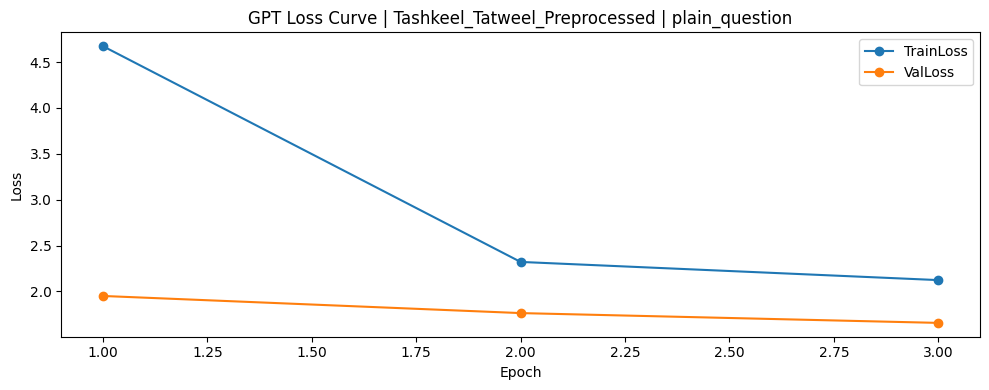

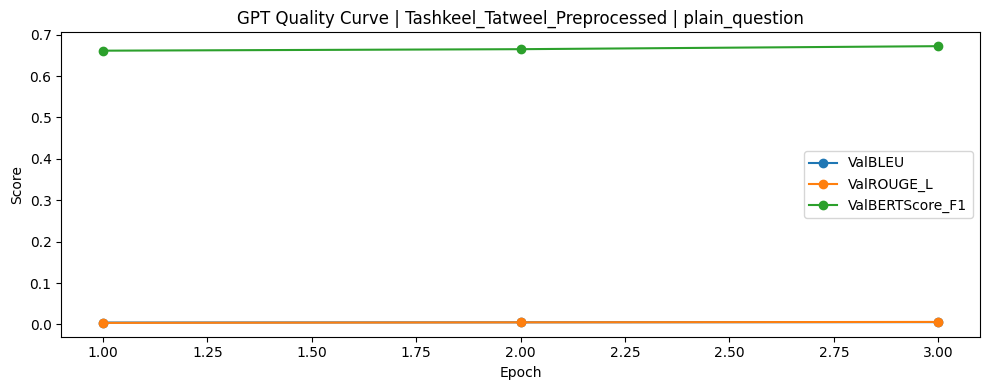

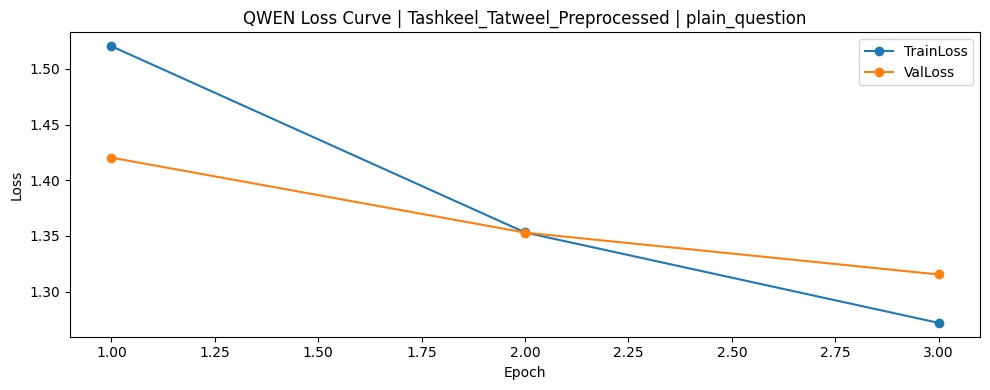

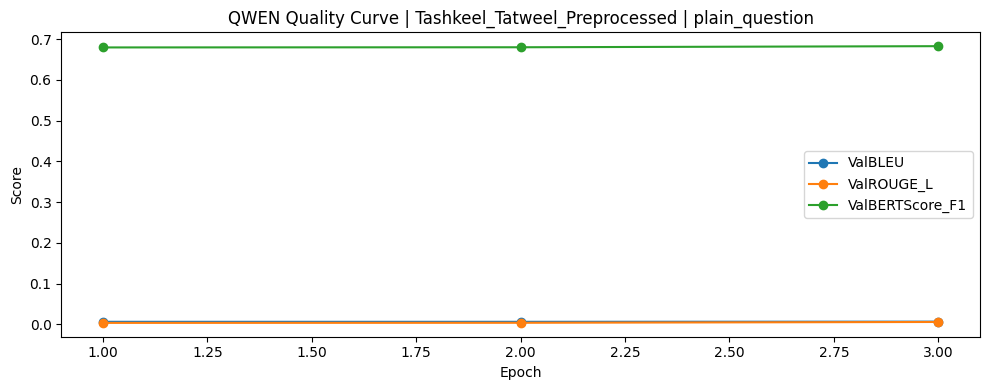

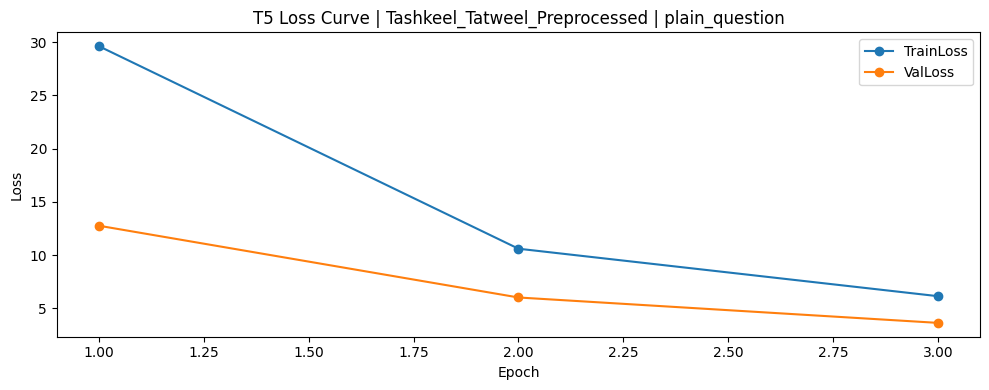

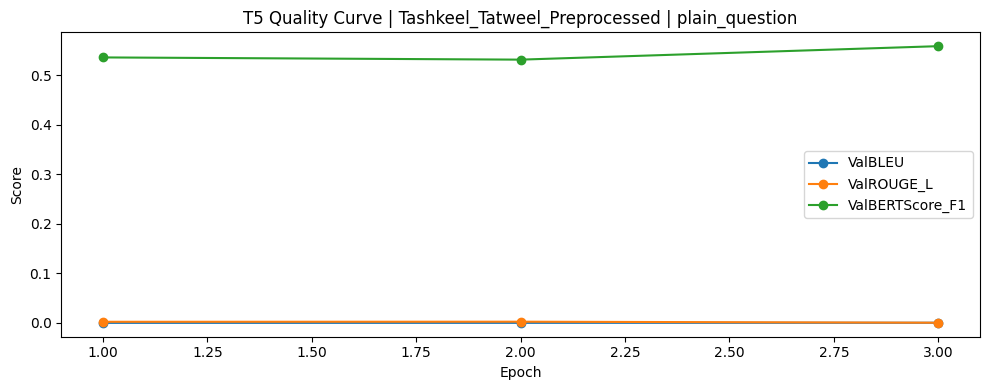

In [17]:
history_frames = [df for df in [gpt_history_df, t5_history_df, qwen_history_df] if not df.empty]
summary_frames = [df for df in [gpt_summary_df, t5_summary_df, qwen_summary_df] if not df.empty]
example_frames = [df for df in [gpt_examples_df, t5_examples_df, qwen_examples_df] if not df.empty]

if history_frames:
    all_history_df = pd.concat(history_frames, ignore_index=True)
    all_summary_df = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
    all_examples_df = pd.concat(example_frames, ignore_index=True) if example_frames else pd.DataFrame()

    detailed_path = os.path.join(OUTPUT_DIR, 'question_answering_transformers_detailed.csv')
    comparison_path = os.path.join(OUTPUT_DIR, 'question_answering_transformers_comparison.csv')
    examples_path = os.path.join(OUTPUT_DIR, 'question_answering_transformers_examples.csv')
    summary_path = os.path.join(OUTPUT_DIR, 'question_answering_transformers_best_summary.csv')
    history_path = os.path.join(OUTPUT_DIR, 'question_answering_transformers_epoch_history.csv')

    all_history_df.to_csv(detailed_path, index=False)
    all_history_df.to_csv(history_path, index=False)
    all_summary_df.to_csv(comparison_path, index=False)
    all_summary_df.to_csv(summary_path, index=False)
    all_examples_df.to_csv(examples_path, index=False)

    print(f'[SAVE] {detailed_path}')
    print(f'[SAVE] {history_path}')
    print(f'[SAVE] {comparison_path}')
    print(f'[SAVE] {summary_path}')
    print(f'[SAVE] {examples_path}')

    if not all_summary_df.empty:
        best_by_model = (
            all_summary_df.sort_values(
                ['Model', 'BestValBERTScore_F1', 'BestValROUGE_L', 'BestValBLEU'],
                ascending=[True, False, False, False]
            )
            .groupby('Model', as_index=False)
            .head(1)
            .reset_index(drop=True)
        )
        manifest = []
        for _, row in best_by_model.iterrows():
            manifest.append({
                'Model': row['Model'],
                'BestDataset': row['Dataset'],
                'InputMode': row['InputMode'],
                'CheckpointPath': row['CheckpointPath'],
                'BestValBLEU': float(row['BestValBLEU']),
                'BestValROUGE_L': float(row['BestValROUGE_L']),
                'BestValBERTScore_F1': float(row['BestValBERTScore_F1']),
                'TestBLEU': float(row['TestBLEU']),
                'TestROUGE_L': float(row['TestROUGE_L']),
                'TestBERTScore_F1': float(row['TestBERTScore_F1']),
            })
        manifest_path = os.path.join(OUTPUT_DIR, 'question_answering_transformers_best_manifest.json')
        with open(manifest_path, 'w', encoding='utf-8') as f:
            json.dump(manifest, f, ensure_ascii=False, indent=2)
        print(f'[SAVE] {manifest_path}')

        display(best_by_model)

        for model_name in sorted(all_history_df['Model'].unique()):
            model_hist = all_history_df[all_history_df['Model'] == model_name].copy()
            best_combo = (
                model_hist.sort_values(['ValBERTScore_F1', 'ValROUGE_L', 'ValBLEU'], ascending=False)
                [['Dataset', 'InputMode']].iloc[0]
            )
            sel = model_hist[(model_hist['Dataset'] == best_combo['Dataset']) & (model_hist['InputMode'] == best_combo['InputMode'])]

            plt.figure(figsize=(10, 4))
            plt.plot(sel['Epoch'], sel['TrainLoss'], marker='o', label='TrainLoss')
            plt.plot(sel['Epoch'], sel['ValLoss'], marker='o', label='ValLoss')
            plt.title(f'{model_name} Loss Curve | {best_combo["Dataset"]} | {best_combo["InputMode"]}')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(10, 4))
            plt.plot(sel['Epoch'], sel['ValBLEU'], marker='o', label='ValBLEU')
            plt.plot(sel['Epoch'], sel['ValROUGE_L'], marker='o', label='ValROUGE_L')
            plt.plot(sel['Epoch'], sel['ValBERTScore_F1'], marker='o', label='ValBERTScore_F1')
            plt.title(f'{model_name} Quality Curve | {best_combo["Dataset"]} | {best_combo["InputMode"]}')
            plt.xlabel('Epoch')
            plt.ylabel('Score')
            plt.legend()
            plt.tight_layout()
            plt.show()
else:
    print('[INFO] No transformer training outputs found yet.')

In [21]:
MODEL_TO_USE = 'AUTO'  # 'AUTO' picks the best available checkpoint from GPT, T5, or QWEN.
HARD_CODED_QUESTIONS = [
    'ما هي أهمية القراءة في تطوير المعرفة؟',
    'كيف يمكن إدارة الوقت بشكل أكثر فعالية؟',
    'ما العوامل التي تساعد على تحقيق النجاح؟',
    'كيف يؤثر النوم الجيد على حياة الإنسان؟',
    'ما أبرز التحديات التي يواجهها الشباب اليوم؟',
    'ما لون السماء؟'
]

AVAILABLE_MODELS = list(MODEL_SPECS.keys())
MODEL_TO_USE = MODEL_TO_USE.upper().strip()
if MODEL_TO_USE == 'AUTO':
    candidate_scores = []
    manifest_path = os.path.join(OUTPUT_DIR, 'question_answering_transformers_best_manifest.json')
    if os.path.exists(manifest_path):
        with open(manifest_path, 'r', encoding='utf-8') as f:
            best_manifest = json.load(f)
        for row in best_manifest:
            candidate_scores.append((
                float(row.get('BestValBERTScore_F1', 0.0)),
                float(row.get('BestValROUGE_L', 0.0)),
                float(row.get('BestValBLEU', 0.0)),
                row['Model'],
                row['CheckpointPath'],
                row
            ))
    if candidate_scores:
        candidate_scores.sort(key=lambda item: (item[0], item[1], item[2]), reverse=True)
        _, _, _, MODEL_TO_USE, selected_ckpt, selected_entry = candidate_scores[0]
    else:
        selected_entry = None
        selected_ckpt = None
        for candidate in ['QWEN', 'GPT', 'T5']:
            candidate_ckpt = os.path.join(CKPT_ROOT, f'best_{candidate}.pt')
            if os.path.exists(candidate_ckpt):
                MODEL_TO_USE = candidate
                selected_ckpt = candidate_ckpt
                selected_entry = None
                break
        if selected_ckpt is None:
            raise FileNotFoundError(f'No checkpoint files found in {CKPT_ROOT}. Train at least one model first.')
else:
    if MODEL_TO_USE not in MODEL_SPECS:
        raise ValueError(f"MODEL_TO_USE must be one of {sorted(MODEL_SPECS)} or AUTO")
    manifest_path = os.path.join(OUTPUT_DIR, 'question_answering_transformers_best_manifest.json')
    selected_ckpt = os.path.join(CKPT_ROOT, f'best_{MODEL_TO_USE}.pt')
    selected_entry = None
    if os.path.exists(manifest_path):
        with open(manifest_path, 'r', encoding='utf-8') as f:
            best_manifest = json.load(f)
        selected_entry = next((row for row in best_manifest if row['Model'] == MODEL_TO_USE), None)
        if selected_entry is not None:
            selected_ckpt = selected_entry['CheckpointPath']
            if not os.path.isabs(selected_ckpt):
                selected_ckpt = os.path.abspath(selected_ckpt)

if not os.path.exists(selected_ckpt):
    raise FileNotFoundError(f'No checkpoint found for {MODEL_TO_USE}: {selected_ckpt}. Train that model first.')

spec = MODEL_SPECS[MODEL_TO_USE]
model_name = spec['hf_name']
family = spec['family']

if selected_entry is not None:
    print(f"[INFO] Loading best checkpoint for {MODEL_TO_USE}")
    print(f"[INFO] Best dataset: {selected_entry['BestDataset']}")
    print(
        f"[INFO] Validation BERTScore-F1: {selected_entry.get('BestValBERTScore_F1', 0.0):.4f} | "
        f"ROUGE-L: {selected_entry.get('BestValROUGE_L', 0.0):.4f} | "
        f"BLEU: {selected_entry.get('BestValBLEU', 0.0):.4f}"
    )
else:
    print(f"[INFO] Loading checkpoint for {MODEL_TO_USE} from {selected_ckpt}")

print(f"[INFO] Checkpoint: {selected_ckpt}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
if family == 'seq2seq':
    tokenizer.padding_side = 'right'
    base_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
else:
    tokenizer.padding_side = 'left'
    base_model = AutoModelForCausalLM.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    base_model.config.pad_token_id = tokenizer.pad_token_id
    base_model.config.eos_token_id = tokenizer.eos_token_id

model = get_peft_model(base_model, build_lora_config(MODEL_TO_USE, family)).to(DEVICE)
state_dict = torch.load(selected_ckpt, map_location=DEVICE)['model_state_dict']
model.load_state_dict(state_dict)
model.eval()
print_trainable_param_stats(model)

def answer_single_question(question: str) -> str:
    prompt = build_input_text(question)
    enc = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=MAX_SRC_LEN, return_attention_mask=True).to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=MAX_TGT_LEN,
            do_sample=True,
            temperature=GEN_TEMPERATURE,
            top_p=GEN_TOP_P,
            repetition_penalty=GEN_REPETITION_PENALTY,
            no_repeat_ngram_size=GEN_NO_REPEAT_NGRAM,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    if family == 'causal':
        prompt_length = int(enc['attention_mask'].sum().item())
        text = _decode_generated_text(tokenizer, out[0], prompt_length, family)
    else:
        text = tokenizer.decode(out[0], skip_special_tokens=True)
    return _strip_question_echo(question, text.strip())

print('\n[TEST] Hard-coded questions')
for idx, question in enumerate(HARD_CODED_QUESTIONS, start=1):
    answer = answer_single_question(question)
    print(f'Q{idx}: {question}')
    print(f'A{idx}: {answer}')
    print('-' * 80)

# print('\n[INTERACTIVE] Type a question and press Enter. Enter \"exit\" to stop.')
# while True:
#     user_question = input('Question: ').strip()
#     if not user_question:
#         continue
#     if user_question.lower() in {'exit', 'quit', 'q'}:
#         print('Stopped interactive QA.')
#         break
#     print('Answer:', answer_single_question(user_question))
#     print('-' * 80)


[INFO] Loading best checkpoint for QWEN
[INFO] Best dataset: Tashkeel_Tatweel_Preprocessed
[INFO] Validation BERTScore-F1: 0.6826 | ROUGE-L: 0.0056 | BLEU: 0.0064
[INFO] Checkpoint: ./outputs/qa_transformer_checkpoints/best_QWEN.pt


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[INFO] Trainable params: 2,162,688 / 496,195,456 (0.44%)

[TEST] Hard-coded questions
Q1: ما هي أهمية القراءة في تطوير المعرفة؟
A1: مهمة الترفيه والتعلم من خلال الإدخاد الفائق، واستخراج المعلومات باستخدام النصوص الحالية والمكتبة الأكتملت للقراءات لتصنيفها وتداولتها على الإنترنت أو بواسطة المؤلفين自带 كتاباً للمطالع بالكتابة اللغوية والتاريخ البارزين. أيضًا يجب أن يكون قراءته بسرعة ومرونة لتلبى عوامل التعقيد مثل اللغة والأدب والإبداع الرقم
--------------------------------------------------------------------------------
Q2: كيف يمكن إدارة الوقت بشكل أكثر فعالية؟
A2: يعتمد على قياس الزمن، استخدام تقنيات التقويم الحديثة للتنظيم والتنقيف المالي والتخطيط الفعال لاستعادة الطاقة عند الحاجزين المتكررين. كما يجب تحسان في المهارات الشخصية للمشاريع الجماعية مثل الزمان اللازم والمراقبة المستدامة وتقليل النتائدة السلبية التي قد تكون بسبب الإجراءات الصناعةliche الأخرى الكهرب
--------------------------------------------------------------------------------
Q3: ما العوامل التي تساعد على تحقيق النجاح؟
A3: 

In [19]:
import os
from IPython.display import FileLink

# 1. Compress the working directory into a zip file
!zip -r /kaggle/working/final_outputs.zip /kaggle/working/*

# 2. Generate a clickable download link
FileLink(r'final_outputs.zip')

  adding: kaggle/working/outputs/ (stored 0%)
  adding: kaggle/working/outputs/question_answering_transformers_examples.csv (deflated 74%)
  adding: kaggle/working/outputs/question_answering_transformers_detailed.csv (deflated 55%)
  adding: kaggle/working/outputs/question_answering_transformers_epoch_history.csv (deflated 55%)
  adding: kaggle/working/outputs/qa_transformer_checkpoints/ (stored 0%)
  adding: kaggle/working/outputs/qa_transformer_checkpoints/best_T5.pt (deflated 53%)
  adding: kaggle/working/outputs/qa_transformer_checkpoints/best_QWEN.pt (deflated 21%)
  adding: kaggle/working/outputs/qa_transformer_checkpoints/best_GPT.pt (deflated 7%)
  adding: kaggle/working/outputs/question_answering_transformers_comparison.csv (deflated 51%)
  adding: kaggle/working/outputs/question_answering_transformers_best_summary.csv (deflated 51%)
  adding: kaggle/working/outputs/question_answering_transformers_best_manifest.json (deflated 67%)


/kaggle/working/final_outputs.zip

In [23]:
print('\n[INTERACTIVE] Type a question and press Enter. Enter \"exit\" to stop.')
while True:
    user_question = input('Question: ').strip()
    if not user_question:
        continue
    if user_question.lower() in {'exit', 'quit', 'q'}:
        print('Stopped interactive QA.')
        break
    print('Answer:', answer_single_question(user_question))
    print('-' * 80)


[INTERACTIVE] Type a question and press Enter. Enter "exit" to stop.


Question:   ما اسم ملك الاردن


Answer: شيخ عثمان بن زيد ابن جعفر ياباني الذي ولد في بلاده عام 723 هـ ويستعمل بدور سلطان للبلاد، كما أنه كان من الأعضاء المكونين لقرية حربة التي تقع على بعد حوالي ربع مليون كيلوغراماً إلى الغنوبور والمنطقة الحضرية للمحيط الهادي أوّل إماراتات بالقرب
--------------------------------------------------------------------------------


Question:  exit


Stopped interactive QA.
